Class Proportions in Train Set:
 acidity_level_encoded
0    0.052292
1    0.646567
2    0.301142
Name: proportion, dtype: float64

Class Proportions in Test Set:
 acidity_level_encoded
0    0.052300
1    0.646567
2    0.301133
Name: proportion, dtype: float64


C:\Users\User\anaconda3\New folder\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\User\AppData\Local\Temp\ipykernel_312\2455982538.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')



Final Macro F1 Score: 0.9937


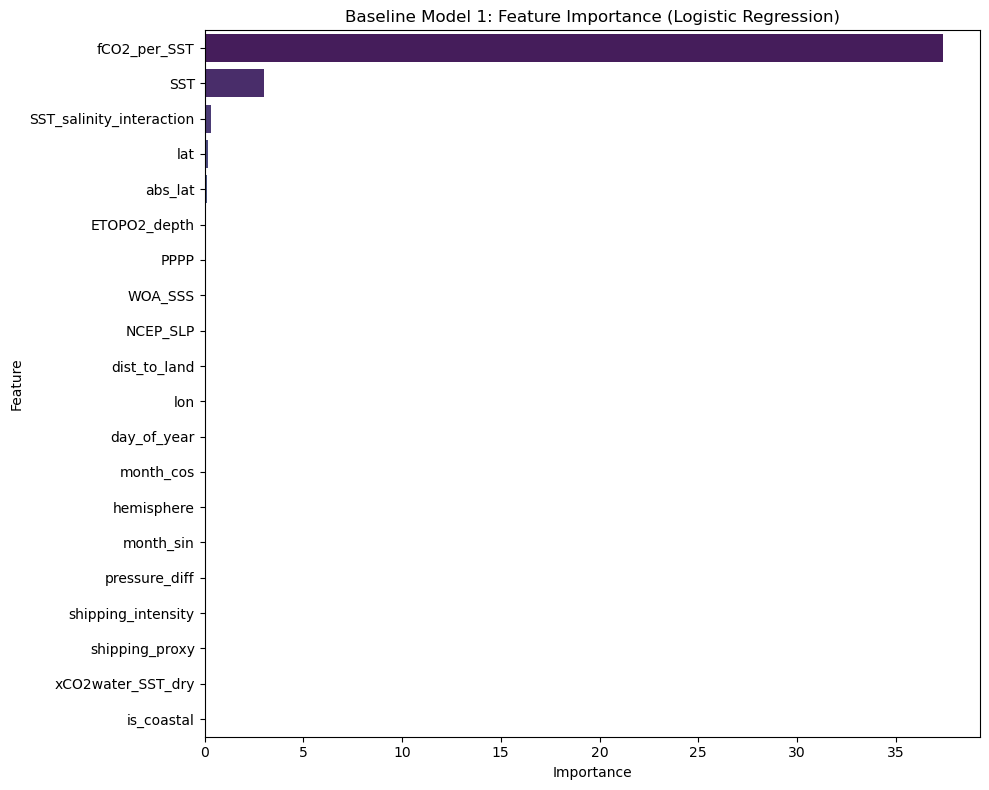

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# 1. Load Data
df = pd.read_csv('ocean_acidity_preprocessed.csv')

# 2. Prepare Features and Target
X = df.drop(columns=['acidity_level', 'acidity_level_encoded'])
y = df['acidity_level_encoded']
feature_names = X.columns

# 3. Stratified Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Check Distribution
print("Class Proportions in Train Set:\n", y_train.value_counts(normalize=True).sort_index())
print("\nClass Proportions in Test Set:\n", y_test.value_counts(normalize=True).sort_index())

# 5. Train Multinomial Logistic Regression
log_reg = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs', 
    max_iter=1000, 
    random_state=42
)
log_reg.fit(X_train, y_train)

# 6. Extract and Plot Feature Importance
# Using mean absolute coefficients across classes
importance = np.mean(np.abs(log_reg.coef_), axis=0)
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Baseline Model 1: Feature Importance (Logistic Regression)')
plt.tight_layout()
plt.savefig('feature_importance.png')

# 7. Final Evaluation
y_pred = log_reg.predict(X_test)
print(f"\nFinal Macro F1 Score: {f1_score(y_test, y_pred, average='macro'):.4f}")